# 数据读取 （data from Unit03_1_5_select.mat）

## 原始数据的读取

In [190]:
import scipy.io
import numpy as np

# ==================== 1️⃣ 读取 .mat 文件 ====================
mat_data = scipy.io.loadmat(
    '/home/charles/HZU/Data_processed/multi-condition-transfer-learning/Unit03_1_5_select_4.mat'
)

data = mat_data['Unit03_1_5_select_4']

print("Original data shape:", data.shape)  # (N, 14)

# ==================== 2️⃣ 设置抽样参数 ====================
n = 5000        # ⭐你只需要改这里
seed = 42      # 可选：保证可复现

np.random.seed(seed)

num_samples = data.shape[0]
assert n <= num_samples, "n cannot be larger than total samples!"

# ==================== 3️⃣ 随机抽取 n 个样本（行） ====================
indices = np.random.choice(num_samples, size=n, replace=False)
data = data[indices, :]

print("Sampled data shape:", data.shape)

# ==================== 4️⃣ 查看抽样结果 ====================
print(data[:5])   # 前 5 行看看


Original data shape: (120000, 14)
Sampled data shape: (5000, 14)
[[ 6.44879007e+00  9.89900780e+00  1.90707862e-01 -1.08997412e+01
   2.62183411e+02  3.11502747e+02  5.61110718e+02  8.06992188e+02
   7.92810608e+02  8.95006958e+02  7.50036987e+02  7.48097046e+02
   7.48671387e+02  2.98820686e+00]
 [ 6.53146410e+00  9.83751106e+00  1.89284369e-01 -1.14709768e+01
   2.62158813e+02  3.12536133e+02  5.60454041e+02  8.14469238e+02
   8.00921570e+02  8.94770813e+02  7.51456848e+02  7.48712585e+02
   7.49641296e+02  4.64089346e+00]
 [ 6.56376362e+00  9.10135174e+00  1.71239838e-01 -1.40106335e+01
   2.62777527e+02  3.08556671e+02  5.62043396e+02  8.09128113e+02
   7.98723511e+02  8.97193604e+02  7.49260986e+02  7.47456848e+02
   7.48115967e+02  2.35006785e+00]
 [ 6.33066225e+00  9.98306084e+00  1.95128351e-01 -1.39515629e+01
   2.63632294e+02  3.07687988e+02  5.75290466e+02  8.21349548e+02
   8.02239624e+02  9.05823181e+02  7.48023193e+02  7.48449585e+02
   7.47242065e+02  8.73057747e+00]
 [ 

## 特征和标签的分离

In [191]:
import numpy as np

# 假设 'data' 是一个二维数组或矩阵
# 分离特征和标签

# 特征是除了最后一列的数据
X = data[:, :-1]  # 所有行，去除最后一列

# 标签是最后一列的数据
y = data[:, -1]  # 所有行，只取最后一列
y = y.reshape(-1, 1)

# # 查看特征和标签
# print("Features (X):")
# print(X[:5])  # 查看前5个特征样本
# print("Labels (y):")
# print(y[:5])  # 查看前5个标签

# 查看特征和标签的形状
print("Shape of Features (X):", X.shape)
print("Shape of Labels (y):", y.shape)

Shape of Features (X): (5000, 13)
Shape of Labels (y): (5000, 1)


## 三集划分

In [192]:
import numpy as np

def interleaved_ratio_split(
    X, y,
    train_ratio=0.6,
    val_ratio=0.2,
    test_ratio=0.2,
    cycle=10
):
    """
    交错隔点划分 + 可控比例
    
    cycle=10 时:
        前 6 -> train
        中 2 -> val
        后 2 -> test
    
    """

    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    X = np.asarray(X)
    y = np.asarray(y).reshape(-1, 1)

    N = len(X)
    idx = np.arange(N)

    n_train = int(train_ratio * cycle)
    n_val   = int(val_ratio * cycle)
    n_test  = cycle - n_train - n_val

    pos = idx % cycle

    train_mask = pos < n_train
    val_mask   = (pos >= n_train) & (pos < n_train + n_val)
    test_mask  = pos >= n_train + n_val

    X_train, y_train = X[train_mask], y[train_mask]
    X_val,   y_val   = X[val_mask],   y[val_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    return X_train, X_val, X_test, y_train, y_val, y_test


# ======================
# 用法示例
# ======================

X_train, X_val, X_test, y_train, y_val, y_test = interleaved_ratio_split(
    X, y,
    train_ratio=0.6,
    val_ratio=0.2,
    test_ratio=0.2,
    cycle=10
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Train: (3000, 13)
Val  : (1000, 13)
Test : (1000, 13)


## 归一化

In [193]:
import numpy as np

# ======================= 1️⃣ X：用 train 的均值和方差 =======================
mu = X_train.mean(axis=0, keepdims=True)     # (1, 13)
std = X_train.std(axis=0, keepdims=True)    # (1, 13)
std[std == 0] = 1e-8

X_train = (X_train - mu) / std
X_val   = (X_val   - mu) / std
X_test  = (X_test  - mu) / std

print("X normalized shapes:")
print(X_train.shape, X_val.shape, X_test.shape)


# ======================= 2️⃣ y：同样只用 train =======================
y_mu = y_train.mean(axis=0, keepdims=True)     # (1,1)
y_std = y_train.std(axis=0, keepdims=True)    # (1,1)
y_std[y_std == 0] = 1e-8

#===========================保留归一化前的y值==============================#
y_train_raw = y_train
y_val_raw = y_val
y_test_raw = y_test


y_train = (y_train - y_mu) / y_std
y_val   = (y_val   - y_mu) / y_std
y_test  = (y_test  - y_mu) / y_std

print("y normalized shapes:")
print(y_train.shape, y_val.shape, y_test.shape)


# ======================= 3️⃣ 反归一化函数 =======================
def inverse_y(y_norm, y_mu, y_std):
    """
    y_norm: normalized prediction, shape [N,1] or [N]
    y_mu, y_std: from training set
    """
    return y_norm * y_std + y_mu


X normalized shapes:
(3000, 13) (1000, 13) (1000, 13)
y normalized shapes:
(3000, 1) (1000, 1) (1000, 1)


# 图结构搭建

In [194]:
# ================================================================
# ⭐ Single-Cell: PINN-style dynamics (dx/dt=f(x)) -> Jacobian graph
#   - dX finite-diff (with dt)
#   - (recommended) per-dim normalize dX for stable training
#   - Early stopping when smoothed loss plateaus
#   - Print trained epochs + fit metrics (MSE/RMSE/MAE/R2 + per-var R2)
#   - Output: edge_index, edge_weight, J_mean  (CPU) for later adj conversion
# ================================================================
import math
from typing import Dict, Optional, Union

import torch
import torch.nn as nn
import torch.nn.functional as F


class _MLPDynamics(nn.Module):
    """dx = f(x) (continuous-time surrogate)."""
    def __init__(self, n_vars: int, hidden: int = 128, depth: int = 3, act: str = "tanh"):
        super().__init__()
        act_layer = {"tanh": nn.Tanh, "relu": nn.ReLU, "gelu": nn.GELU}[act.lower()]
        layers = []
        for i in range(depth):
            in_dim = n_vars if i == 0 else hidden
            layers += [nn.Linear(in_dim, hidden), act_layer()]
        layers += [nn.Linear(hidden, n_vars)]
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def pinn_build_graph_from_X(
    X: Union[torch.Tensor, "numpy.ndarray"],
    *,
    dt: float = 1.0,
    # dynamics surrogate
    hidden: int = 128,
    depth: int = 3,
    act: str = "tanh",
    epochs: int = 800,
    lr: float = 1e-3,
    weight_decay: float = 1e-6,
    batch_size: int = 256,
    lam_weak_phy: float = 0.0,
    # graph extraction
    topk: int = 5,
    symmetrize: bool = False,
    self_loop: bool = False,
    # jacobian sampling
    jac_samples: int = 256,
    jac_stride: int = 1,
    # compute
    device: Optional[Union[str, torch.device]] = None,
    seed: int = 0,
    return_model: bool = False,
    # ===== NEW: stabilize training on derivative scale =====
    normalize_dx: bool = True,
    # ===== NEW: early stopping =====
    early_stop: bool = True,
    patience: int = 30,
    min_rel_improve: float = 1e-4,
    smooth_win: int = 10,
    print_every: int = 50,
) -> Dict[str, torch.Tensor]:

    torch.manual_seed(seed)

    # ---- tensorize ----
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X, dtype=torch.float32)
    else:
        X = X.float()

    if X.ndim != 2:
        raise ValueError(f"X must be 2D [T, N], got shape {tuple(X.shape)}")

    T, N = X.shape
    if T < 3:
        raise ValueError("X must have at least 3 time steps to compute finite differences.")

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    X = X.to(device)

    # -----------------------------
    # 0) Finite-difference dx/dt (targets)
    # -----------------------------
    dX = torch.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2.0 * dt)
    dX[0]    = (X[1] - X[0]) / dt
    dX[-1]   = (X[-1] - X[-2]) / dt

    with torch.no_grad():
        print("\n========== Input Stats ==========")
        print(f"X   : mean={float(X.mean()):.6f}, std={float(X.std()):.6f}, abs_max={float(X.abs().max()):.6f}")
        print(f"dX  : mean={float(dX.mean()):.6f}, std={float(dX.std()):.6f}, abs_max={float(dX.abs().max()):.6f}")
        print(f"dt  : {dt}")

    # -----------------------------
    # 0.5) (Optional) per-dimension normalize dX
    # -----------------------------
    if normalize_dx:
        dX_mean = dX.mean(dim=0, keepdim=True)
        dX_std  = dX.std(dim=0, keepdim=True) + 1e-6
        dXn = (dX - dX_mean) / dX_std
    else:
        dX_mean = torch.zeros(1, N, device=device)
        dX_std  = torch.ones(1, N, device=device)
        dXn = dX

    # -----------------------------
    # 1) Train dynamics surrogate
    # -----------------------------
    model = _MLPDynamics(N, hidden=hidden, depth=depth, act=act).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    def weak_phy(x: torch.Tensor, dx_pred: torch.Tensor) -> torch.Tensor:
        # stability-ish regularizer: penalize large d/dt ||x||^2 = 2 x·dx
        d_energy = 2.0 * (x * dx_pred).sum(dim=1)
        return (d_energy**2).mean()

    idx_all = torch.arange(T, device=device)

    loss_hist = []
    best_smooth = float("inf")
    bad_count = 0
    stopped_epoch = epochs

    model.train()
    for ep in range(1, epochs + 1):
        perm = idx_all[torch.randperm(T, device=device)]
        epoch_loss = 0.0
        n_batches = 0

        for s in range(0, T, batch_size):
            b = perm[s:s + batch_size]
            bx = X[b]
            bdx = dXn[b]  # train on normalized derivative target

            pred = model(bx)
            loss = F.mse_loss(pred, bdx)

            if lam_weak_phy > 0:
                loss = loss + lam_weak_phy * weak_phy(bx, pred)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            epoch_loss += float(loss.item())
            n_batches += 1

        epoch_loss /= max(1, n_batches)
        loss_hist.append(epoch_loss)

        # smooth loss
        if len(loss_hist) >= smooth_win:
            smooth_loss = sum(loss_hist[-smooth_win:]) / smooth_win
        else:
            smooth_loss = sum(loss_hist) / len(loss_hist)

        # early stopping check
        if early_stop:
            rel_improve = (best_smooth - smooth_loss) / (abs(best_smooth) + 1e-12)

            if smooth_loss < best_smooth and rel_improve > min_rel_improve:
                best_smooth = smooth_loss
                bad_count = 0
            else:
                bad_count += 1

        if (ep % print_every == 0) or (ep == 1):
            if early_stop:
                print(f"[Epoch {ep:04d}] epoch_loss={epoch_loss:.6e} | smooth={smooth_loss:.6e} | bad_count={bad_count}/{patience}")
            else:
                print(f"[Epoch {ep:04d}] epoch_loss={epoch_loss:.6e} | smooth={smooth_loss:.6e}")

        if early_stop and bad_count >= patience:
            stopped_epoch = ep
            print(f"\n🛑 Early stop triggered at epoch {ep} (smoothed loss plateaued).")
            break

    print(f"✅ Training finished. Trained epochs: {stopped_epoch}/{epochs}")

    # -----------------------------
    # 1.5) Evaluate fit quality on ORIGINAL dX scale
    # -----------------------------
    model.eval()
    with torch.no_grad():
        pred_n = model(X)                    # normalized derivative prediction
        pred_all = pred_n * dX_std + dX_mean # back to original dX scale

        mse  = F.mse_loss(pred_all, dX).item()
        rmse = math.sqrt(mse)
        mae  = torch.mean(torch.abs(pred_all - dX)).item()

        ss_res = torch.sum((pred_all - dX) ** 2)
        ss_tot = torch.sum((dX - dX.mean()) ** 2) + 1e-12
        r2 = (1 - ss_res / ss_tot).item()

        r2_each = []
        for i in range(N):
            yi = dX[:, i]
            pi = pred_all[:, i]
            ss_res_i = torch.sum((pi - yi) ** 2)
            ss_tot_i = torch.sum((yi - yi.mean()) ** 2) + 1e-12
            r2_each.append((1 - ss_res_i / ss_tot_i).item())

    print("\n=========== Dynamics Fit Metrics (original dX scale) ===========")
    print(f"MSE  : {mse:.6e}")
    print(f"RMSE : {rmse:.6e}")
    print(f"MAE  : {mae:.6e}")
    print(f"R^2  : {r2:.6f}")
    print("R^2 per variable:", [round(v, 3) for v in r2_each])

    # -----------------------------
    # 2) Jacobian-based sensitivity matrix (w.r.t normalized-output model)
    # -----------------------------
    cand = torch.arange(0, T, step=max(1, jac_stride), device=device)
    if cand.numel() > jac_samples:
        pick = torch.linspace(0, cand.numel() - 1, steps=jac_samples, device=device).long()
        sample_idx = cand[pick]
    else:
        sample_idx = cand

    J_acc = torch.zeros(N, N, device=device)

    for k in sample_idx.tolist():
        x = X[k:k+1].clone().detach().requires_grad_(True)  # [1, N]
        fx = model(x)  # [1, N] normalized dx/dt

        J = torch.zeros(N, N, device=device)
        for i in range(N):
            grad = torch.autograd.grad(
                outputs=fx[0, i],
                inputs=x,
                retain_graph=True,
                create_graph=False,
                allow_unused=False,
            )[0]  # [1, N]
            J[i, :] = grad[0, :]

        J_acc += J.abs()

    J_mean = (J_acc / float(len(sample_idx))).detach()  # [N, N]

    # -----------------------------
    # 3) Build edge_index / edge_weight via top-k parents per node
    # -----------------------------
    edge_src, edge_dst, edge_w = [], [], []
    k_eff = min(max(1, topk), N - 1) if N > 1 else 0

    for i in range(N):
        scores = J_mean[i].clone()
        if not self_loop:
            scores[i] = 0.0

        if k_eff > 0:
            parents = torch.topk(scores, k=k_eff, largest=True).indices
            for j in parents.tolist():
                if (not self_loop) and (j == i):
                    continue
                w = float(J_mean[i, j].item())
                if w <= 0:
                    continue
                edge_src.append(j)
                edge_dst.append(i)
                edge_w.append(w)

    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long, device=device)
    edge_weight = torch.tensor(edge_w, dtype=torch.float32, device=device)

    if symmetrize and edge_index.numel() > 0:
        rev = torch.stack([edge_index[1], edge_index[0]], dim=0)
        edge_index = torch.cat([edge_index, rev], dim=1)
        edge_weight = torch.cat([edge_weight, edge_weight], dim=0)

    out = {
        "edge_index": edge_index.detach().cpu(),
        "edge_weight": edge_weight.detach().cpu(),
        "J_mean": J_mean.detach().cpu(),
    }
    if return_model:
        out["model"] = model
        out["dX_mean"] = dX_mean.detach().cpu()
        out["dX_std"]  = dX_std.detach().cpu()

    return out


# ============================================================
# ✅ Run (assumes X_train is already prepared, shape [T, N])
# ============================================================
print("X_train shape:", X_train.shape)

graph_dict = pinn_build_graph_from_X(
    X_train,
    dt=0.05,          # replace with your real sampling interval if known
    hidden=128,
    depth=3,
    act="tanh",
    epochs=600,
    lr=1e-3,
    weight_decay=1e-6,
    batch_size=256,
    lam_weak_phy=0.01,
    topk=8,
    jac_samples=300,
    jac_stride=1,
    symmetrize=False,
    self_loop=False,
    normalize_dx=False,  # recommended
    early_stop=False,    # requested
    patience=30,
    min_rel_improve=1e-4,
    smooth_win=10,
    print_every=50,
)

edge_index  = graph_dict["edge_index"]
edge_weight = graph_dict["edge_weight"]
J_mean      = graph_dict["J_mean"]

N = X_train.shape[1]

print("\n=========== Graph Summary ===========")
print("Number of nodes  :", N)
print("Number of edges  :", edge_index.shape[1])
print("edge_index shape :", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)

print("\nFirst 15 edges (j -> i):")
for k in range(min(15, edge_index.shape[1])):
    j = edge_index[0, k].item()
    i = edge_index[1, k].item()
    w = edge_weight[k].item()
    print(f"{j} -> {i}, weight = {w:.6f}")

print("\nSensitivity matrix J_mean (top-left 6x6):")
print(J_mean[:6, :6])


X_train shape: (3000, 13)

========== Input Stats ==========
X   : mean=0.000000, std=1.000013, abs_max=18.328327
dX  : mean=0.001043, std=14.187020, abs_max=187.197388
dt  : 0.05
[Epoch 0001] epoch_loss=2.027468e+02 | smooth=2.027468e+02
[Epoch 0050] epoch_loss=1.999838e+02 | smooth=1.990748e+02
[Epoch 0100] epoch_loss=1.908294e+02 | smooth=1.913314e+02
[Epoch 0150] epoch_loss=1.775847e+02 | smooth=1.784667e+02
[Epoch 0200] epoch_loss=1.616252e+02 | smooth=1.631084e+02
[Epoch 0250] epoch_loss=1.473311e+02 | smooth=1.478108e+02
[Epoch 0300] epoch_loss=1.348357e+02 | smooth=1.364011e+02
[Epoch 0350] epoch_loss=1.241648e+02 | smooth=1.257224e+02
[Epoch 0400] epoch_loss=1.174558e+02 | smooth=1.175009e+02
[Epoch 0450] epoch_loss=1.092828e+02 | smooth=1.101340e+02
[Epoch 0500] epoch_loss=1.030785e+02 | smooth=1.044332e+02
[Epoch 0550] epoch_loss=9.912756e+01 | smooth=9.889464e+01
[Epoch 0600] epoch_loss=9.432521e+01 | smooth=9.387304e+01
✅ Training finished. Trained epochs: 600/600

=======

In [195]:
import torch

def edge_to_adj_for_variablegcn(
    edge_index: torch.Tensor,
    edge_weight: torch.Tensor,
    num_nodes: int,
    *,
    add_self_loop: bool = True,
    normalize: str = "sym",   # ✅方案1：对称归一化  D^{-1/2} A D^{-1/2}
    eps: float = 1e-12,
    device=None,
    make_symmetric: bool = False,   # 可选：先把有向边对称化，再做 sym-norm
) -> torch.Tensor:
    """
    Convert (edge_index, edge_weight) -> dense adj [D, D] compatible with VariableGCN.

    edge_index: [2, E]  (src=j, dst=i)  means j -> i
    edge_weight: [E]

    Returns:
      adj: [D, D] float32 on `device`

    normalize:
      - "sym":  D^{-1/2} (A + I) D^{-1/2}   (GCN常用，✅方案1)
      - "row":  row-normalize (你的旧方案)
      - "none": no normalization
    """
    if device is None:
        device = edge_index.device

    edge_index = edge_index.to(device)
    edge_weight = edge_weight.to(device).float()

    D = int(num_nodes)
    A = torch.zeros(D, D, device=device, dtype=torch.float32)

    src = edge_index[0].long()
    dst = edge_index[1].long()

    # Fill: A[dst, src] = weight  (einsum("ij,bjf->bif") aggregates from j -> i)
    A.index_put_((dst, src), edge_weight, accumulate=True)

    # (optional) make undirected before adding self-loop + sym norm
    if make_symmetric:
        A = 0.5 * (A + A.t())

    # add self-loop
    if add_self_loop:
        A = A + torch.eye(D, device=device, dtype=torch.float32)

    # normalization
    if normalize == "sym":
        deg = A.sum(dim=1).clamp_min(eps)              # [D]
        deg_inv_sqrt = torch.pow(deg, -0.5)            # [D]
        D_inv_sqrt = torch.diag(deg_inv_sqrt)          # [D,D]
        adj = D_inv_sqrt @ A @ D_inv_sqrt              # [D,D]
    elif normalize == "row":
        adj = A / (A.sum(dim=1, keepdim=True) + eps)
    elif normalize == "none":
        adj = A
    else:
        raise ValueError(f"normalize must be 'sym'|'row'|'none', got {normalize}")

    return adj


# =======================
# ✅ Example: with your PINN graph output
# =======================
D = X_train.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

edge_index_t  = edge_index.to(device)
edge_weight_t = edge_weight.to(device)

adj = edge_to_adj_for_variablegcn(
    edge_index=edge_index_t,
    edge_weight=edge_weight_t,
    num_nodes=D,
    add_self_loop=True,
    normalize="sym",        # ✅方案1：对称归一化
    make_symmetric=False,   # 若你想把有向图变无向再卷，改成 True
    device=device,
)

print("adj shape:", adj.shape)
print("adj dtype:", adj.dtype)
print("adj row-sum (first 5):", adj.sum(dim=1)[:5])   # sym-norm 不保证行和=1（正常）
print("adj diag (first 5):", adj.diag()[:5])          # 自环项会存在

# 现在 adj 可直接喂给 VariableGCN
# encoder = VariableGCN(hidden=13).to(device)
# X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
# X_train_embedding = encoder(X_train_t, adj)
# print(X_train_embedding.shape)


adj shape: torch.Size([13, 13])
adj dtype: torch.float32
adj row-sum (first 5): tensor([0.8987, 1.1308, 0.9416, 0.8250, 0.9897], device='cuda:0')
adj diag (first 5): tensor([0.0089, 0.0058, 0.0084, 0.0109, 0.0076], device='cuda:0')


# 模型

## 表征学习模型

### 表征学习模型定义

In [196]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class VariableGCN(nn.Module):
    """
    One-layer Variable GCN Encoder (adjacency matrix input)
    """

    def __init__(self, hidden=32):
        super().__init__()

        # scalar → node embedding
        self.input_proj = nn.Linear(1, hidden)

        # GCN linear
        self.weight = nn.Linear(hidden, hidden)

    def forward(self, X, adj):
        """
        X:   [B, D]
        adj: [D, D]
        """

        # [B,D] → [B,D,1] → [B,D,H]
        X = self.input_proj(X.unsqueeze(-1))

        # Graph propagation
        H = torch.einsum("ij,bjf->bif", adj, X)

        # Linear + activation
        H = F.relu(self.weight(H))

        # Pool over variables
        g = H.mean(dim=1)

        return g
    
class VariableGCN_Temporal(nn.Module):
    """
    VariableGCN + Temporal Feature Fusion (GRU)
    """

    def __init__(
        self,
        var_gcn: VariableGCN,
        hidden_var: int,
        hidden_temporal: int = 64,
        num_layers: int = 1,
    ):
        super().__init__()

        self.var_gcn = var_gcn

        # 时序融合（你也可以换成 LSTM / Transformer）
        self.gru = nn.GRU(
            input_size=hidden_var,
            hidden_size=hidden_temporal,
            num_layers=num_layers,
            batch_first=True,
        )

        # 示例：回归头
        self.head = nn.Linear(hidden_temporal, 1)

    def forward(self, X_seq, adj):
        """
        X_seq: [B, T, D]
        adj:   [D, D]
        """

        B, T, D = X_seq.shape
        g_list = []

        # -------- 变量图编码（逐时间步） --------
        for t in range(T):
            g_t = self.var_gcn(X_seq[:, t, :], adj)   # [B, H_var]
            g_list.append(g_t)

        G = torch.stack(g_list, dim=1)                # [B, T, H_var]

        # -------- 时序融合 --------
        out, _ = self.gru(G)                          # [B, T, H_temp]
        z = out[:, -1, :]                             # last time step

        y = self.head(z)                              # [B, 1]
        return y


### 表征学习模型训练

In [197]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

adj = torch.tensor(adj, dtype=torch.float32).to(device)
# D = adj.size(0)
# adj = adj + torch.eye(D, device=device)
# adj = adj / adj.sum(dim=1, keepdim=True)

# 1) 先特征融合模型（保持你原来用法）
encoder = VariableGCN(hidden=13).to(device)

# ---- 兼容：X_train 可以是 [B,D] 或 [B,T,D]
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).to(device)

# 如果没有时间维，自动扩成 [B,1,D]，保证后续时序模块可运行
def ensure_seq(X):
    if X.dim() == 2:   # [B,D]
        return X.unsqueeze(1)  # -> [B,1,D]
    elif X.dim() == 3: # [B,T,D]
        return X
    else:
        raise ValueError(f"X must be [B,D] or [B,T,D], got {tuple(X.shape)}")

X_train_seq = ensure_seq(X_train_t)
X_val_seq   = ensure_seq(X_val_t)

# 先做一次“单步特征融合”的输出检查（与原代码一致逻辑）
# 如果是 [B,T,D]，这里取 t=0 做示例检查
X_train_embedding = encoder(X_train_seq[:, 0, :], adj)
print("Feature-fused embedding (train) shape:", X_train_embedding.shape)  # [B, 13]

X_val_embedding = encoder(X_val_seq[:, 0, :], adj)
print("Feature-fused embedding (val) shape  :", X_val_embedding.shape)    # [B, 13]


# ============================================================
# ✅ 2) 再时序融合：把 encoder 嵌入到 GRU 时序模型里
# ============================================================
temporal_model = VariableGCN_Temporal(
    var_gcn=encoder,
    hidden_var=13,          # 必须等于 VariableGCN(hidden=?)
    hidden_temporal=64,
    num_layers=1
).to(device)

# 前向：输出回归值 [B,1]
y_train_pred = temporal_model(X_train_seq, adj)
y_val_pred   = temporal_model(X_val_seq, adj)

print("Temporal-fused output (train) shape:", y_train_pred.shape)  # [B,1]
print("Temporal-fused output (val) shape  :", y_val_pred.shape)    # [B,1]

Feature-fused embedding (train) shape: torch.Size([3000, 13])
Feature-fused embedding (val) shape  : torch.Size([1000, 13])
Temporal-fused output (train) shape: torch.Size([3000, 1])
Temporal-fused output (val) shape  : torch.Size([1000, 1])


/tmp/ipykernel_17256/145342791.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  adj = torch.tensor(adj, dtype=torch.float32).to(device)


## 回归模型

### 回归模型定义

In [198]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BSpline1D(nn.Module):
    """
    Simple learnable 1D B-spline (uniform knots) for KAN edges.
    Input:  [B, in_dim]
    Output: [B, out_dim]
    """
    def __init__(self, in_dim, out_dim, num_knots=8):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.num_knots = num_knots

        # 控制点系数（每个输入维到每个输出维）
        self.coeff = nn.Parameter(torch.randn(in_dim, out_dim, num_knots) * 0.01)

        # 均匀结点（固定）
        self.register_buffer("knots", torch.linspace(-3, 3, num_knots))

    def forward(self, x):
        # x: [B, in_dim]
        # 计算每个 knot 的基函数权重（高斯核近似 B-spline，稳定可导）
        # phi: [B, in_dim, num_knots]
        x_exp = x.unsqueeze(-1)                         # [B, in_dim, 1]
        phi = torch.exp(-((x_exp - self.knots)**2))    # RBF 近似 spline basis
        phi = phi / (phi.sum(dim=-1, keepdim=True) + 1e-8)

        # 加权求和到 out_dim
        # out[b, o] = sum_i sum_k phi[b,i,k] * coeff[i,o,k]
        out = torch.einsum('bik,iok->bo', phi, self.coeff)
        return out


class KANLayer(nn.Module):
    """
    One KAN layer: y = Wb * SiLU(x) + Ws * Spline(x)
    """
    def __init__(self, in_dim, out_dim, num_knots=8):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=True)   # Wb * SiLU(x)
        self.spline = BSpline1D(in_dim, out_dim, num_knots=num_knots)  # Ws * Spline(x)

    def forward(self, x):
        return self.lin(F.silu(x)) + self.spline(x)


class KANRegressor(nn.Module):
    """
    Prediction head used in AKGNN (KAN).
    Input:  g [B, D]   (graph-aggregated features)
    Output: y [B, 1]
    """
    def __init__(self, in_dim, hidden=64, num_knots=8):
        super().__init__()
        self.kan1 = KANLayer(in_dim, hidden, num_knots=num_knots)
        self.kan2 = KANLayer(hidden, hidden, num_knots=num_knots)
        self.out  = nn.Linear(hidden, 1)

    def forward(self, g):
        h = self.kan1(g)
        h = self.kan2(h)
        y = self.out(h)
        return y



### 回归模型训练

In [199]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import numpy as np
from sklearn.metrics import r2_score

# ======================= 0️⃣ numpy → torch =======================

X_train_ebeding = torch.tensor(X_train_ebedding, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_ebeding = torch.tensor(X_val_ebedding, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

# ======================= 1️⃣ Dataset / Loader =======================

batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=batch_size,
    shuffle=False
)

# ======================= 2️⃣ Model =======================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

D = X_train.shape[1]   # 13

model = KANRegressor(in_dim=D, hidden=64, num_knots=8).to(device)

# ======================= 3️⃣ Optimizer / Loss =======================

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

# ======================= 4️⃣ Train / Val Loop =======================

num_epochs = 200

best_val_rmse = float("inf")
SAVE_PATH = "/home/charles/HZU/Industrial_Software_Testing/Industrial_Software_Testing/multi_condition_transfer_learning/transfer_learning_v1/result/model_save/best_kan_model.pt"

for epoch in range(1, num_epochs + 1):

    # -------- Train --------
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)

        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    # -------- Validation --------
    model.eval()
    val_loss = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)

            val_loss += criterion(pred, yb).item() * xb.size(0)

            y_true.append(yb.cpu().numpy())
            y_pred.append(pred.cpu().numpy())

    val_loss /= len(val_loader.dataset)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    val_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    val_r2 = r2_score(y_true, y_pred)

    # ======================= ⭐ 保存最优模型 =======================
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"✅ Best model updated at epoch {epoch}, Val RMSE = {val_rmse:.4f},Val R2: {val_r2:.4f}")

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"[Epoch {epoch:03d}] "
            f"Train MSE: {train_loss:.4f} | "
            f"Val RMSE: {val_rmse:.4f} | "
            f"Val R2: {val_r2:.4f}"
        )

print(f"\n🎯 Training finished. Best Val RMSE: {best_val_rmse:.4f}")
print(f"Model saved to: {SAVE_PATH}")



/tmp/ipykernel_17256/3966986454.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_ebeding = torch.tensor(X_train_ebedding, dtype=torch.float32)
/tmp/ipykernel_17256/3966986454.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val_ebeding = torch.tensor(X_val_ebedding, dtype=torch.float32)


✅ Best model updated at epoch 1, Val RMSE = 0.7671,Val R2: 0.3424
[Epoch 001] Train MSE: 0.7084 | Val RMSE: 0.7671 | Val R2: 0.3424
✅ Best model updated at epoch 2, Val RMSE = 0.7490,Val R2: 0.3731
✅ Best model updated at epoch 4, Val RMSE = 0.7463,Val R2: 0.3776
✅ Best model updated at epoch 5, Val RMSE = 0.7457,Val R2: 0.3786
✅ Best model updated at epoch 6, Val RMSE = 0.7357,Val R2: 0.3952
✅ Best model updated at epoch 7, Val RMSE = 0.7139,Val R2: 0.4305
✅ Best model updated at epoch 9, Val RMSE = 0.7080,Val R2: 0.4399
[Epoch 010] Train MSE: 0.5249 | Val RMSE: 0.7168 | Val R2: 0.4259
✅ Best model updated at epoch 11, Val RMSE = 0.7078,Val R2: 0.4402
✅ Best model updated at epoch 12, Val RMSE = 0.7075,Val R2: 0.4407
✅ Best model updated at epoch 15, Val RMSE = 0.7062,Val R2: 0.4428
✅ Best model updated at epoch 17, Val RMSE = 0.7058,Val R2: 0.4434
[Epoch 020] Train MSE: 0.4918 | Val RMSE: 0.7080 | Val R2: 0.4398
✅ Best model updated at epoch 21, Val RMSE = 0.7048,Val R2: 0.4449
✅ Bes

# 测试

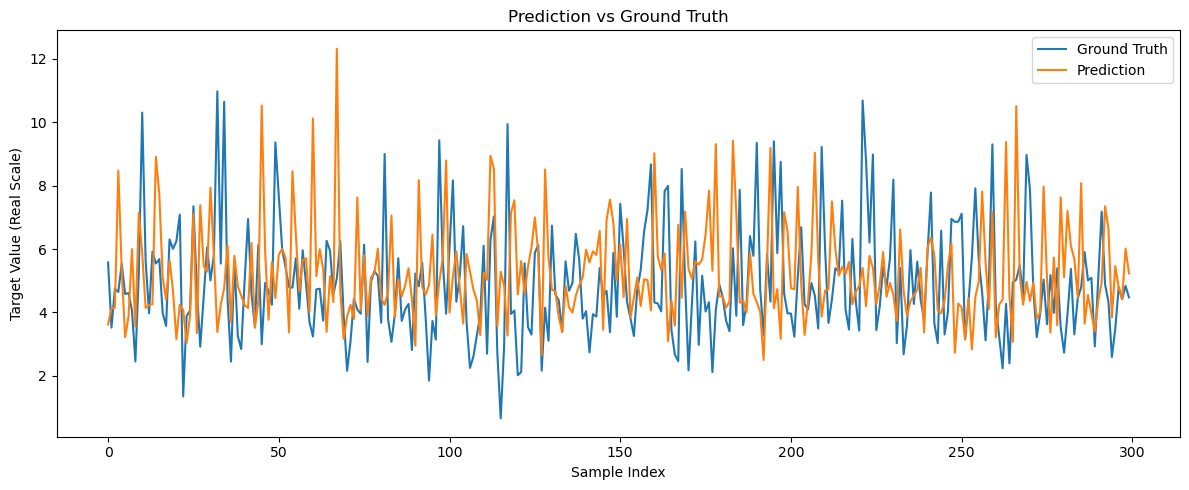

✅ Test R² (normalized): 0.7219


In [201]:
from sklearn.metrics import r2_score
import numpy as np
import torch
import matplotlib.pyplot as plt

# ======================= 0️⃣ numpy → torch =======================

X_test_t = torch.tensor(X_train, dtype=torch.float32)
y_test_t = torch.tensor(y_train, dtype=torch.float32)

@torch.no_grad()
def evaluate_r2_and_plot(model, X_data, y_data, batch_size, y_test_raw, y_mu, y_std):
    model.eval()

    y_true_list = []
    y_pred_list = []

    num_samples = X_data.shape[0]

    for start in range(0, num_samples, batch_size):
        Xb = X_data[start:start + batch_size].to(device)
        yb = y_data[start:start + batch_size].to(device)

        y_hat = model(Xb)

        y_true_list.append(yb.view(-1).cpu().numpy())
        y_pred_list.append(y_hat.view(-1).cpu().numpy())

    # ===== 拼接 =====
    y_true_norm = np.concatenate(y_true_list)
    y_pred_norm = np.concatenate(y_pred_list)

    # ===== R2 (normalized space) =====
    r2 = r2_score(y_true_norm, y_pred_norm)

    # ===== 反归一化预测 =====
    y_pred_real = y_pred_norm * y_std + y_mu
    y_pred_real = y_pred_real.flatten()

    # ===== 真实值直接用 raw =====
    y_true_real = y_test_raw.reshape(-1)

    # ===== 画图 =====
    plt.figure(figsize=(12, 5))

    plt.plot(y_true_real[:300], label="Ground Truth")
    plt.plot(y_pred_real[:300], label="Prediction")

    plt.legend()
    plt.xlabel("Sample Index")
    plt.ylabel("Target Value (Real Scale)")
    plt.title("Prediction vs Ground Truth")

    plt.tight_layout()
    plt.show()

    return r2, y_true_real, y_pred_real

r2, y_true_real, y_pred_real = evaluate_r2_and_plot(
    model,
    X_test_t,
    y_test_t,
    batch_size,
    y_test_raw,
    y_mu,
    y_std
)

print(f"✅ Test R² (normalized): {r2:.4f}")

